# Puno Quechua — Data Exploration

Two datasets from Mozilla Data Collective (CC0):
- **Scripted** — speakers read fixed sentences → clean transcripts, easy to validate
- **Spontaneous** — speakers respond naturally to prompts → messier, but real speech

In [21]:
import os, glob
import pandas as pd
import matplotlib.pyplot as plt
import librosa, librosa.display
import numpy as np
import IPython.display as ipd

SCRIPTED_TSV   = 'scripted/cv-corpus-25.0-2026-03-09/qxp/validated.tsv'
SPONT_TSV      = 'spontaneous/sps-corpus-3.0-2026-03-09-qxp/ss-corpus-qxp.tsv'
SCRIPTED_CLIPS = 'scripted/cv-corpus-25.0-2026-03-09/qxp/clips'
SPONT_CLIPS    = 'spontaneous/sps-corpus-3.0-2026-03-09-qxp/audios'

df_s = pd.read_csv(SCRIPTED_TSV, sep='\t')
df_p = pd.read_csv(SPONT_TSV, sep='\t')

## Overview

In [22]:
pd.DataFrame({
    'clips':           [len(df_s), len(df_p)],
    'speakers':        [df_s['client_id'].nunique(), df_p['client_id'].nunique()],
    'transcribed':     [len(df_s), int(df_p['transcription'].notna().sum())],
    'avg duration':    ['~5s (not in TSV)', f"{df_p['duration_ms'].mean()/1000:.1f}s"],
    'total hours':     ['~31h validated', f"{df_p['duration_ms'].sum()/1000/3600:.1f}h"],
    'female clips':    [int((df_s['gender']=='female_feminine').sum()), int((df_p['gender']=='female_feminine').sum())],
    'male clips':      [int((df_s['gender']=='male_masculine').sum()), int((df_p['gender']=='male_masculine').sum())],
    'unknown gender':  [int(df_s['gender'].isna().sum()), int(df_p['gender'].isna().sum())],
}, index=['scripted', 'spontaneous']).T

,scripted,spontaneous
clips,22727,7286
speakers,77,110
transcribed,22727,1222
avg duration,~5s (not in TSV),17.4s
total hours,~31h validated,35.3h
female clips,16079,5150
male clips,308,427
unknown gender,6340,1709


## Sample rows

In [23]:
df_s.head()

,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment
0,0af18d417177a707fb1bcb22e6b23aa10944f4e44ec80e...,common_voice_qxp_42192187.mp3,122e2be2a8a1f3f227f0752cf84e5946fd4b0c4e53ad4c...,Irqikuna paykunapura qatipayanakunku.,"agriculture_food,agriculture_food,finance,heal...",2,0,NaN,NaN,NaN,NaN,qxp,NaN
1,76b24fbe885ee8fdad9aa7dd591b82c6fa01fdc5eeb366...,common_voice_qxp_48799942.mp3,d29d38892e4b3567b7521914846f256a7a40089c9115bf...,Juan wayqichampaq waqayninta pichan.,"general,agriculture_food,nature_environment",4,0,thirties,NaN,Puno,NaN,qxp,NaN
2,87382b51a62cecd09092de5114d0bb779a4e61ce39e6e7...,common_voice_qxp_48816803.mp3,d858fd4486ab61cd0a4ff73466f8e236a4cb7b88484da9...,Hayk'aqmi runa Killaman chayarqan?,"general,agriculture_food,healthcare",6,0,twenties,female_feminine,Puno|Macusani - Puno,NaN,qxp,NaN
3,cbd0c73038ebd1636ed7d8211b650f8b4e47dedf03168b...,common_voice_qxp_48887267.mp3,5b4e0f5c19f8cf67909d4b80acdeca7382352a0a72dc90...,Pipaqmi kay qillqasqa?,"general,agriculture_food,healthcare",2,0,fifties,female_feminine,NaN,NaN,qxp,NaN
4,e0c301044db611e861f7117cfcc2ee744f03bffd69122a...,common_voice_qxp_48781894.mp3,d4e94ecb06930998e2e9ac40f49c3f5771081dd9d89897...,Iskay urququnaq chaupinpi payqa tiyan.,"general,agriculture_food,history_law_government",2,0,thirties,female_feminine,NaN,NaN,qxp,NaN


In [24]:
df_p.head()

,client_id,audio_id,audio_file,duration_ms,prompt_id,prompt,transcription,votes,age,gender,accents,variant,language,prompt_upvotes,prompt_reports,is_edited,split,char_per_sec,quality_tags
0,52b99da1457acebd59f609f330ab5dc7,34189,spontaneous-speech-qxp-34189.mp3,33264,4374,Taytaykimanta willarikamuy.,"Taytayqa uywa hampiqmi, payqa wayna kasparaqmi...",1,thirties,male_masculine,"Nuñoa, Puno",NaN,Puno Quechua,0,0,0,test,7.635883,NaN
1,52b99da1457acebd59f609f330ab5dc7,34190,spontaneous-speech-qxp-34190.mp3,21708,4363,Imaynataq chiri tiyasqaykipi?,"Chiriqa pasaq, rit'imun chinkaytaraqmi, chayma...",1,thirties,male_masculine,"Nuñoa, Puno",NaN,Puno Quechua,0,0,0,test,7.232357,NaN
2,52b99da1457acebd59f609f330ab5dc7,34191,spontaneous-speech-qxp-34191.mp3,18216,4382,Imaynatan yacharqanki qichwa rimayta?,"Qichwa rimaytaqa mamitaymanta yachaqarqani, pa...",1,thirties,male_masculine,"Nuñoa, Puno",NaN,Puno Quechua,0,0,0,test,8.399209,NaN
3,52b99da1457acebd59f609f330ab5dc7,34192,spontaneous-speech-qxp-34192.mp3,21492,4387,Pitaq wayk'uyta yachachirqasunki?,"Wayk'uytaqa nuqaqa yachakuni, mamitayta qhawap...",1,thirties,male_masculine,"Nuñoa, Puno",NaN,Puno Quechua,0,0,0,test,8.096036,NaN
4,52b99da1457acebd59f609f330ab5dc7,34193,spontaneous-speech-qxp-34193.mp3,20124,4362,Llaqtaykimanta rimaykuy.,"Llaqtayqa huch'uylla, thak, urqukunawan muyuri...",1,thirties,male_masculine,"Nuñoa, Puno",NaN,Puno Quechua,0,0,0,test,7.056251,NaN


## Demographics

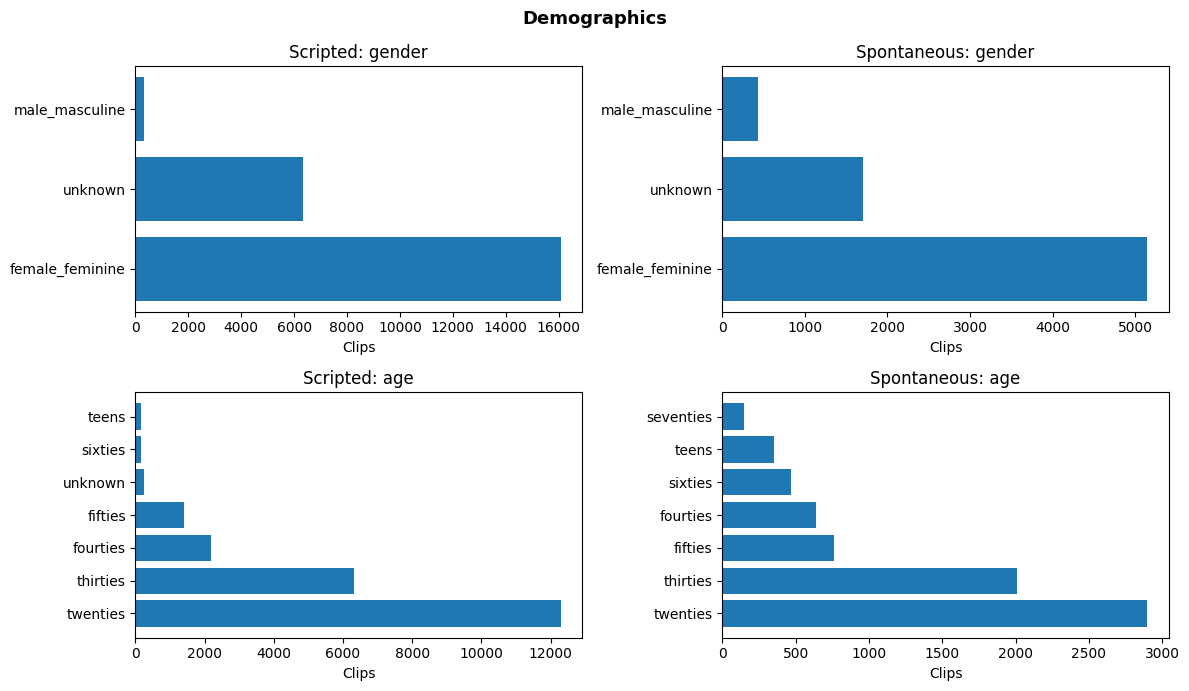

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle('Demographics', fontsize=13, fontweight='bold')

for ax, df, label, col in [
    (axes[0,0], df_s, 'Scripted',    'gender'),
    (axes[0,1], df_p, 'Spontaneous', 'gender'),
    (axes[1,0], df_s, 'Scripted',    'age'),
    (axes[1,1], df_p, 'Spontaneous', 'age'),
]:
    counts = df[col].fillna('unknown').value_counts()
    ax.barh(counts.index, counts.values)
    ax.set_title(f'{label}: {col}')
    ax.set_xlabel('Clips')

plt.tight_layout()
plt.show()

## Transcript length

Scripted sentences are short and fixed. Spontaneous responses are longer and vary a lot.

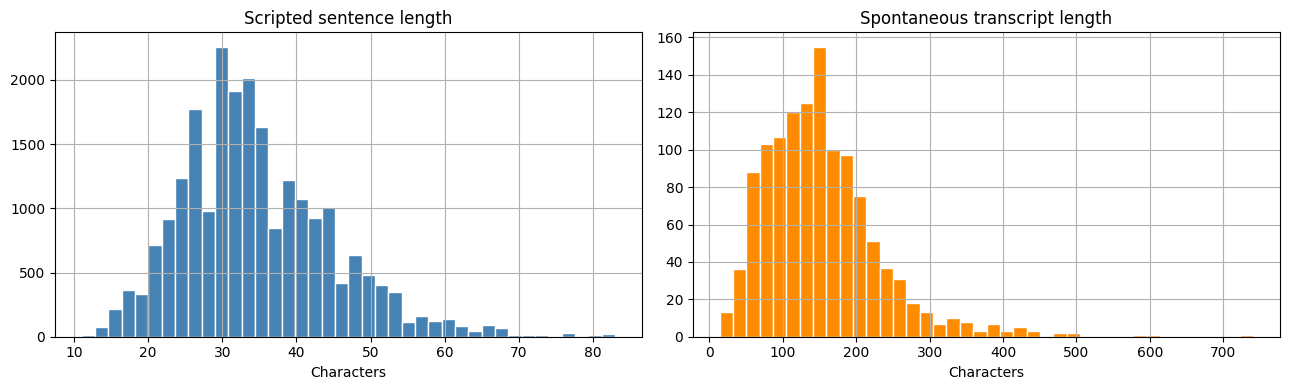

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df_s['sentence'].dropna().str.len().hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Scripted sentence length')
axes[0].set_xlabel('Characters')

df_p['transcription'].dropna().str.len().hist(bins=40, ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Spontaneous transcript length')
axes[1].set_xlabel('Characters')

plt.tight_layout()
plt.show()

## Spontaneous — clip duration

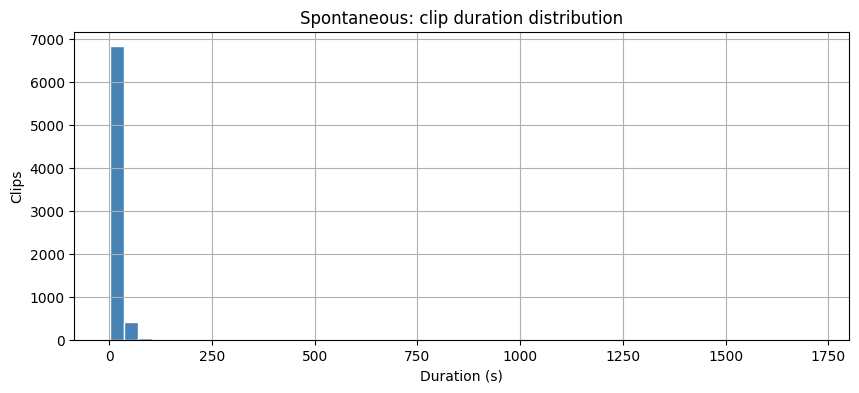

In [27]:
fig, ax = plt.subplots(figsize=(10, 4))
(df_p['duration_ms'] / 1000).hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Duration (s)')
ax.set_ylabel('Clips')
ax.set_title('Spontaneous: clip duration distribution')
plt.show()

## Listen to clips

Waveform, mel spectrogram, and audio player for one clip from each dataset.

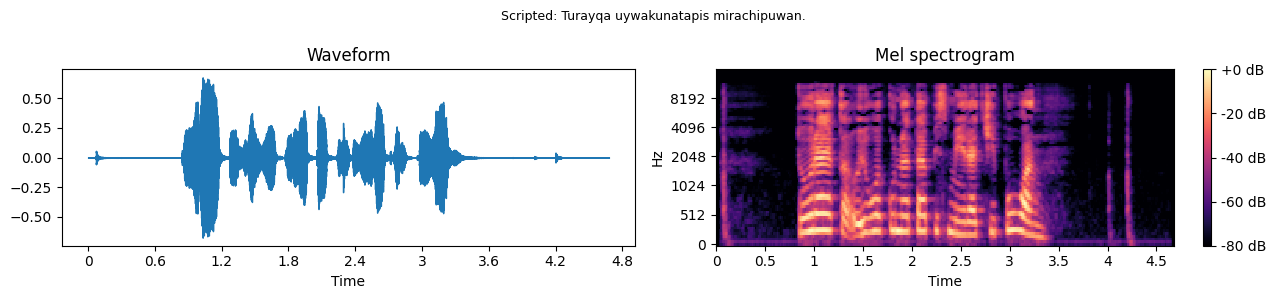

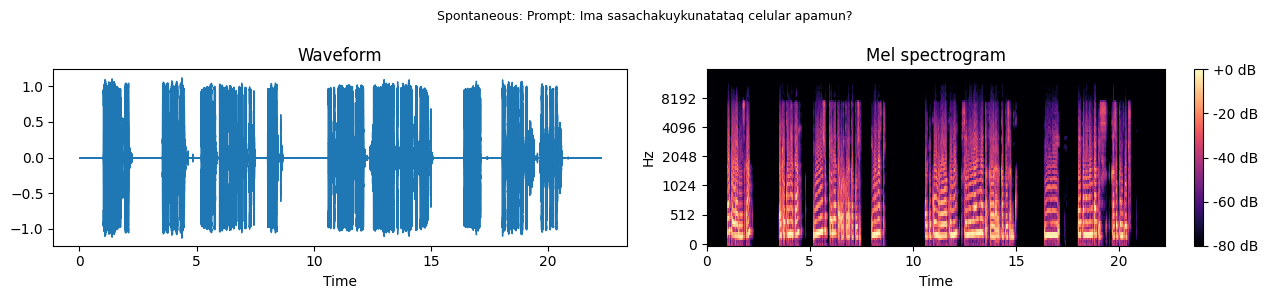

In [28]:
def show_clip(audio_path, title=''):
    y, sr = librosa.load(audio_path, sr=None)
    fig, axes = plt.subplots(1, 2, figsize=(13, 3))
    librosa.display.waveshow(y, sr=sr, ax=axes[0])
    axes[0].set_title('Waveform')
    S_db = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=sr, n_mels=80), ref=np.max)
    img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[1])
    fig.colorbar(img, ax=axes[1], format='%+2.0f dB')
    axes[1].set_title('Mel spectrogram')
    plt.suptitle(title, fontsize=9)
    plt.tight_layout()
    plt.show()
    display(ipd.Audio(audio_path))

# scripted
scripted_files = glob.glob(f'{SCRIPTED_CLIPS}/*.mp3')
if scripted_files:
    fname = os.path.basename(scripted_files[0])
    row = df_s[df_s['path'] == fname]
    sentence = row.iloc[0]['sentence'] if len(row) else fname
    show_clip(scripted_files[0], f'Scripted: {sentence}')

# spontaneous
spont_files = glob.glob(f'{SPONT_CLIPS}/*.mp3')
if spont_files:
    fname = os.path.basename(spont_files[0])
    row = df_p[df_p['audio_file'] == fname]
    if len(row):
        r = row.iloc[0]
        label = f"Prompt: {r['prompt']}" + (f"  |  {r['transcription']}" if pd.notna(r['transcription']) else '')
    else:
        label = fname
    show_clip(spont_files[0], f'Spontaneous: {label}')